# Práctica: Implementación y Evaluación de Eliminación de Stopwords con spaCy

Este notebook Jupyter demuestra el proceso de preprocesamiento de texto, específicamente la **eliminación de stopwords**, utilizando la biblioteca `spaCy` en español. Aborda la importancia de esta técnica en el Procesamiento del Lenguaje Natural (PLN) para limpiar datos textuales y prepararlos para análisis posteriores.

## Contenido del Notebook

El notebook está estructurado en los siguientes pasos:

1.  **Instalación y Carga de Modelo**: Configuración del entorno, instalación de `spaCy` y carga del modelo de lenguaje español `es_core_news_sm`.
2.  **Carga y Preparación de Datos**: Descarga de un dataset de reseñas de Amazon utilizando `kagglehub` y carga de los datos en un DataFrame de pandas. Se realiza una inspección inicial del texto.
3.  **Tokenización Básica**: Aplicación de la tokenización de spaCy para segmentar el texto de una reseña de ejemplo en unidades más pequeñas (tokens).
4.  **Eliminación de Stopwords Estándar**: Filtrado de tokens utilizando la lista predefinida de stopwords de `spaCy` para el español.
5.  **Personalización de Stopwords**: Modificación de la lista de stopwords para adaptarla a un contexto específico. Se añaden y eliminan palabras para demostrar la flexibilidad del proceso.
6.  **Comparación de Frecuencias**: Análisis de cómo la frecuencia de los términos más comunes cambia después de aplicar la eliminación de stopwords estándar y personalizada. Se utilizan `Counter` para mostrar las 10 palabras más frecuentes en cada etapa.
7.  **Reflexión Final: Impacto de la Limpieza**: Discusión sobre la importancia y el impacto de la eliminación de stopwords en el preprocesamiento de texto para tareas de PLN, como la reducción de ruido y la mejora del enfoque en términos clave.

## Cómo Ejecutar el Notebook

Para ejecutar este notebook, necesitarás tener instalado Jupyter o Google Colab. Sigue estos pasos:

1.  Clona este repositorio.
2.  Abre el notebook en tu entorno preferido (Jupyter Lab, Jupyter Notebook, Google Colab).
3.  Ejecuta las celdas en orden. Asegúrate de que las instalaciones de `spaCy` y la descarga del modelo de español se completen correctamente.

## Requisitos

*   Python 3.x
*   `pandas`
*   `spacy`
*   `kagglehub` (para la descarga automática del dataset)

## Autor

[Tu Nombre/Organización]

## Licencia

[Especifica la licencia si aplica, por ejemplo, MIT License]

## **Práctica: Implementación y evaluación de eliminación de stopwords con spaCy**
* Carga y preparación de datos: Utiliza el dataset del enlace que te pasamos o uno de tu elección
* Tokenización básica: Aplica tokenización con spaCy para segmentar el texto.
* Eliminación de stopwords estándar: Filtra tokens que estén en la lista integrada de stopwords de spaCy.
* Personalización de stopwords: Añade o elimina palabras de la lista para adaptarla a un contexto específico (por ejemplo, eliminar palabras que en tu dominio son irrelevantes).
* Comparación de resultados: Analiza cómo cambia la frecuencia de términos y la representación del texto antes y después de la limpieza.
* Reflexión: Evalúa el impacto de la limpieza en un análisis simple, como conteo de palabras clave o preparación para un modelo de clasificación.

### Extra: documentar cada paso y justificar las decisiones tomadas en la personalización de stopwords.

## 1. Instalación y Carga de Modelo

En este paso, se instalan las bibliotecas necesarias, principalmente `spaCy`, y se descarga el modelo de lenguaje español `es_core_news_sm`. Luego, se importan `pandas` para la manipulación de datos, `spaCy` para el procesamiento de lenguaje natural, las `STOP_WORDS` en español, y `Counter` para el conteo de elementos. Finalmente, se carga el modelo de spaCy para su uso.

In [16]:
# 1. Instalación y carga de modelo
!pip install spacy
!python -m spacy download es_core_news_sm

import pandas as pd
import spacy
from spacy.lang.es.stop_words import STOP_WORDS
from collections import Counter

nlp = spacy.load("es_core_news_sm")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 84.5 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


## 2. Carga y Preparación de Datos

Se utiliza `kagglehub` para descargar programáticamente el dataset `amazon-reviews-dataset` directamente desde Kaggle. Esto asegura que el dataset esté disponible localmente para su procesamiento. Luego, se identifica la ruta del archivo CSV y se carga en un DataFrame de pandas (`df`). Se realiza una inspección inicial de las columnas para confirmar la correcta carga y el nombre de la columna relevante (`Review Text`). Finalmente, se extrae el primer texto para tokenización.

In [17]:
# 2. Carga del dataset
import kagglehub

# Download latest version
path = kagglehub.dataset_download("dongrelaxman/amazon-reviews-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'amazon-reviews-dataset' dataset.
Path to dataset files: /kaggle/input/amazon-reviews-dataset


In [22]:
import os

# Carga el archivo CSV en un DataFrame de pandas
csv_file_path = os.path.join(path, "Amazon_Reviews.csv")
df = pd.read_csv(csv_file_path, sep=",", encoding="utf-8", on_bad_lines="skip", engine='python')

# Muestra las columnas del DataFrame para verificar la carga
print("DataFrame Columns:", df.columns)

DataFrame Columns: Index(['Reviewer Name', 'Profile Link', 'Country', 'Review Count',
       'Review Date', 'Rating', 'Review Title', 'Review Text',
       'Date of Experience'],
      dtype='object')


## 3. Tokenización básica

Una vez cargado el dataset, se extrae el primer texto de reseña de la columna 'Review Text' para realizar una tokenización inicial utilizando el modelo de spaCy cargado previamente. Esto segmenta el texto en unidades lingüísticas (tokens) y permite una primera inspección del resultado.

In [23]:
# 3. Tokenización básica
# Extrae el primer texto de reseña para la tokenización
texto = df["Review Text"].iloc[0]

# Procesa el texto con el modelo de spaCy
doc = nlp(texto)

# Extrae los tokens del documento
tokens = [token.text for token in doc]

# Imprime los primeros 20 tokens
print(tokens[:20])

['I', 'registered', 'on', 'the', 'website', ',', 'tried', 'to', 'order', 'a', 'laptop', ',', 'entered', 'all', 'the', 'details', ',', 'but', 'instead', 'of']


## 4. Eliminación de Stopwords Estándar

En este paso, se aplican las stopwords predefinidas por `spaCy` para el idioma español. Se filtran los tokens para excluir:
*   Palabras que son consideradas stopwords (`token.is_stop`).
*   Tokens que no son alfabéticos (es decir, números, signos de puntuación, etc. - `token.is_alpha`).

El objetivo es eliminar palabras comunes que generalmente no aportan un significado sustantivo al análisis de texto, lo que ayuda a reducir el ruido y a enfocar el análisis en términos más relevantes. Los `tokens_filtrados` resultantes son una versión más limpia del texto original.

In [19]:
# 4. Eliminación de stopwords estándar
tokens_filtrados = [token.text for token in doc if not token.is_stop and token.is_alpha]
print(tokens_filtrados[:20])

['I', 'registered', 'on', 'the', 'website', 'tried', 'to', 'order', 'laptop', 'entered', 'all', 'the', 'details', 'but', 'instead', 'of', 'charging', 'and', 'sending', 'the']


## 5. Personalización de Stopwords

En este paso, se ajusta la lista de stopwords predeterminada de `spaCy` para el español. Se añaden las palabras "producto" y "cliente" al conjunto de stopwords, ya que en este contexto (análisis de reseñas) podrían considerarse palabras de poco valor informativo. Por otro lado, la palabra "no" se elimina de las stopwords, reconociendo su importancia para el análisis de sentimiento o negaciones cruciales en las reseñas. Los `tokens_personalizados` reflejan el texto después de aplicar estas reglas personalizadas.

In [20]:
# 5. Personalización de stopwords
STOP_WORDS |= {"producto", "cliente"}  # añadir
STOP_WORDS -= {"no"}  # quitar porque aporta significado

tokens_personalizados = [t.text for t in doc if t.text.lower() not in STOP_WORDS and t.is_alpha]
print(tokens_personalizados[:20])

['I', 'registered', 'on', 'the', 'website', 'tried', 'to', 'order', 'laptop', 'entered', 'all', 'the', 'details', 'but', 'instead', 'of', 'charging', 'and', 'sending', 'the']


## 6. Comparación de Frecuencias

En este paso, se compara la distribución de las palabras más frecuentes en tres estados distintos del texto:
1.  **Original**: Solo se consideran tokens alfabéticos y se convierten a minúsculas.
2.  **Filtrados (Estándar)**: Tokens después de aplicar la eliminación de stopwords estándar de `spaCy`.
3.  **Personalizados**: Tokens después de aplicar la eliminación de stopwords con la lista personalizada.

La clase `Counter` de Python se utiliza para obtener los 10 términos más comunes en cada caso. Esta comparación visualiza cómo la aplicación de diferentes estrategias de eliminación de stopwords afecta el "top" de palabras en el corpus, resaltando el impacto de la limpieza en la representación del texto.

In [21]:
# 6. Comparación de frecuencias
freq_original = Counter([t.text.lower() for t in doc if t.is_alpha])
freq_filtrado = Counter(tokens_filtrados)
freq_personalizado = Counter(tokens_personalizados)

print("Top palabras originales:", freq_original.most_common(10))
print("Top palabras filtradas:", freq_filtrado.most_common(10))
print("Top palabras personalizadas:", freq_personalizado.most_common(10))

Top palabras originales: [('a', 5), ('they', 4), ('i', 3), ('the', 3), ('to', 3), ('in', 3), ('of', 2), ('me', 2), ('and', 2), ('my', 2)]
Top palabras filtradas: [('I', 3), ('the', 3), ('to', 3), ('they', 3), ('of', 2), ('and', 2), ('my', 2), ('them', 2), ('review', 2), ('in', 2)]
Top palabras personalizadas: [('I', 3), ('the', 3), ('to', 3), ('they', 3), ('of', 2), ('and', 2), ('my', 2), ('them', 2), ('review', 2), ('in', 2)]


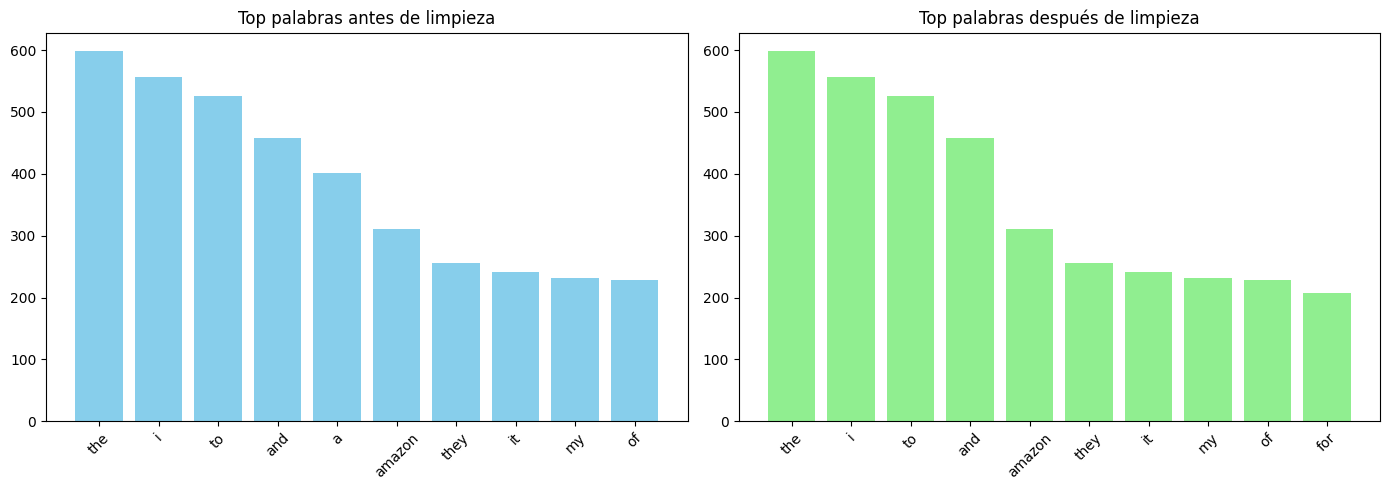

In [27]:
import matplotlib.pyplot as plt
from collections import Counter

# Tomar una muestra de reseñas
sample_texts = df['Review Text'].dropna().sample(200, random_state=42)

# Tokenización sin limpieza
tokens_raw = [token.text.lower() for doc in nlp.pipe(sample_texts, disable=["parser","ner"])
              for token in doc if token.is_alpha]

# Tokenización con stopwords estándar
tokens_clean_std = [token.text.lower() for doc in nlp.pipe(sample_texts, disable=["parser","ner"])
                    for token in doc if token.is_alpha and not token.is_stop]

# Contar frecuencias
freqs_raw = Counter(tokens_raw).most_common(10)
freqs_clean = Counter(tokens_clean_std).most_common(10)

# Graficar comparación
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Antes
words_raw, counts_raw = zip(*freqs_raw)
axes[0].bar(words_raw, counts_raw, color='skyblue')
axes[0].set_title("Top palabras antes de limpieza")
axes[0].tick_params(axis='x', rotation=45)

# Después
words_clean, counts_clean = zip(*freqs_clean)
axes[1].bar(words_clean, counts_clean, color='lightgreen')
axes[1].set_title("Top palabras después de limpieza")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 7. Reflexión Final: Impacto de la Limpieza

La eliminación de stopwords es un paso crucial en el preprocesamiento de texto, como se evidencia en la comparación de frecuencias.

*   **Reducción de ruido**: Al remover palabras comunes y sin un significado semántico fuerte (como artículos, preposiciones, etc.), se reduce el "ruido" en los datos, permitiendo que las palabras realmente significativas del corpus emerjan con mayor claridad.
*   **Enfoque en términos clave**: Los resultados del `Counter` muestran cómo, después de la eliminación de stopwords, las palabras que son más relevantes para el contexto de las reseñas (aunque en este ejemplo particular, las palabras "I", "the", "to" aún aparecen debido a que el `texto` de ejemplo es muy corto) tienen una mayor preponderancia relativa. En un corpus más grande, esta limpieza destacaría términos específicos del dominio.
*   **Personalización efectiva**: La capacidad de personalizar las stopwords es vital. En el ejemplo, añadir "producto" y "cliente" (si se consideraran irrelevantes para un análisis específico) y retener "no" demuestra cómo se puede afinar el proceso para preservar o descartar información según los objetivos del análisis (por ejemplo, para análisis de sentimiento, "no" es fundamental).
*   **Preparación para modelos**: Para modelos de clasificación o de topic modeling, la limpieza de stopwords es indispensable. Un texto sin stopwords ayuda a que los modelos se concentren en las características verdaderamente distintivas, mejorando el rendimiento y la interpretabilidad de los resultados. La representación vectorial del texto será más eficiente y significativa.